# INT4量化

In [5]:
import numpy as np

# 有些会用非对称的量化范围，也就是-0代表-8，用二进制表示就是1000，这样的一个表示范围就是[-8, 7]
# 用-7到7的原因是为了保证量化的对称性（正负范围相等），能使得零点精确对应到0
int4_row = np.array([-7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7])
print(int4_row)

factor = np.abs(int4_row).max()
int4_level = int4_row / factor
print(int4_level)

[-7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7]
[-1.         -0.85714286 -0.71428571 -0.57142857 -0.42857143 -0.28571429
 -0.14285714  0.          0.14285714  0.28571429  0.42857143  0.57142857
  0.71428571  0.85714286  1.        ]


In [6]:
x = np.array([3.7, -0.2, 1.6]) / 3.7
print(x)
# [7, 0, 3] # int4

[ 1.         -0.05405405  0.43243243]


# INT4量化数画图

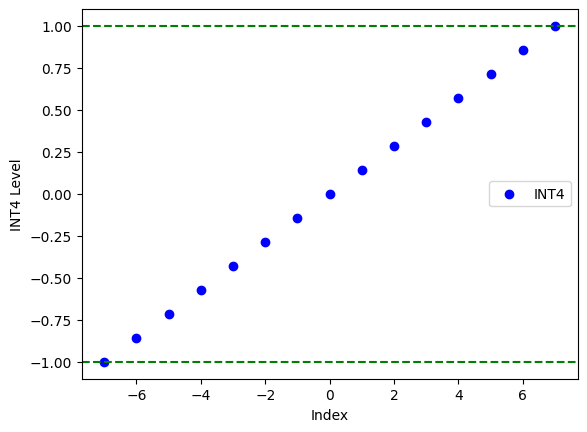

In [8]:
import matplotlib.pyplot as plt

plt.axhline(y=1, color="green", linestyle='--')
plt.axhline(y=-1, color="green", linestyle='--')

plt.scatter(int4_row, int4_level, c='blue', label="INT4")
plt.xlabel("Index")
plt.ylabel("INT4 Level")
plt.legend()


[0.9677083, 0.9092447625, 0.850781225, 0.7923176875, 0.73385415, 0.6753906125, 0.616927075, 0.5584635375]
[0.9677083, 0.9008928285714285, 0.8340773571428571, 0.7672618857142857, 0.7004464142857143, 0.6336309428571428, 0.5668154714285714]


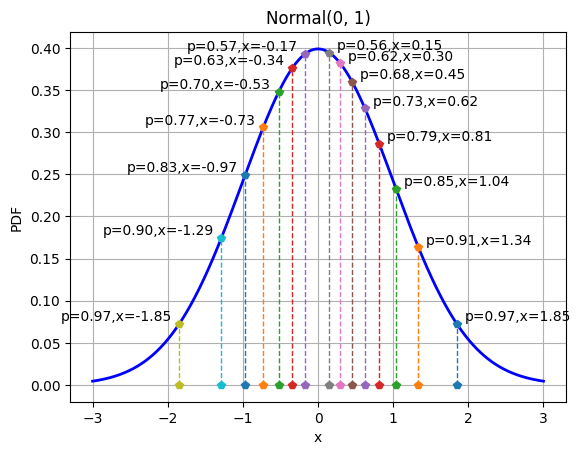

In [18]:
# NF4量化数的物理意义（分位数）
from scipy.stats import norm

# 偏移量
offset = 0.9677083

# 先画一个正态分布的曲线
x = np.linspace(-3, 3, 1000)
y = norm.pdf(x, 0, 1) # 标准正态分布Normal(0, 1)
plt.plot(x, y, 'b-', linewidth=2)

# 画正数部分
prob_list = np.linspace(offset, 0.5, 9)[:-1].tolist()
print(prob_list)
for prob in prob_list:
    x_prob = norm.ppf(prob, 0, 1) # 根据 y 轴的概率计算对应横坐标 x
    y_prob = norm.pdf(x_prob, 0, 1) # 根据 x 轴计算指定处的概率函数取值 y
    plt.plot([x_prob, x_prob], [0, y_prob], 'p--', linewidth=1)
    plt.text(x_prob+0.1, y_prob, f"p={prob:.2f},x={x_prob:.2f}", ha='left', va='bottom')

# 画负数部分
prob_list = np.linspace(offset, 0.5, 8)[:-1].tolist()
print(prob_list)
for prob in prob_list:
    x_prob = -norm.ppf(prob, 0, 1) # 根据 y 轴的概率计算对应横坐标 x
    y_prob = norm.pdf(x_prob, 0, 1) # 根据 x 轴计算指定处的概率函数取值 y
    plt.plot([x_prob, x_prob], [0, y_prob], 'p--', linewidth=1)
    plt.text(x_prob-0.1, y_prob, f"p={prob:.2f},x={x_prob:.2f}", ha='right', va='bottom')

plt.xlabel("x")
plt.ylabel("PDF")
plt.title("Normal(0, 1)")
plt.grid(True)


# 计算NF4的量化常数

In [21]:
import torch

def create_normal_map(offset = 0.9677083):
    # 正数部分（8）
    v1 = norm.ppf(torch.linspace(offset, 0.5, 9, dtype=torch.float64)[:-1]).tolist()

    # 0
    v2 = [0]

    # 负数部分（7）
    v3 = (-norm.ppf(torch.linspace(offset, 0.5, 8, dtype=torch.float64)[:-1])).tolist()

    v = v1 + v2 + v3
    values = np.array(v)
    values.sort()
    values /= np.max(values)
    return values

values = create_normal_map()
print("NF4 量化数:", values)

NF4 量化数: [-1.         -0.69619289 -0.52507304 -0.39491749 -0.28444136 -0.18477344
 -0.09104999  0.          0.07958033  0.16093017  0.24611229  0.33791519
  0.4407098   0.56261697  0.72295673  1.        ]


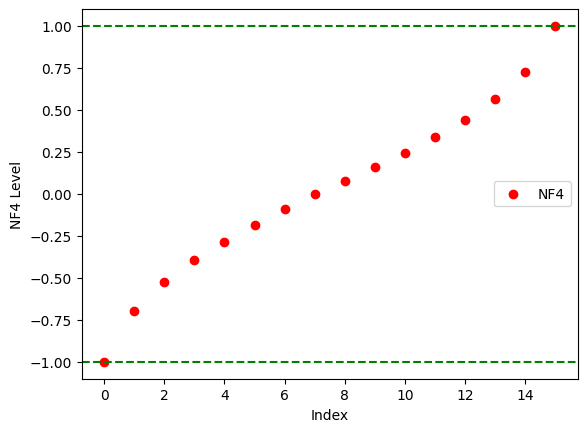

In [26]:
plt.axhline(y=1, color="green", linestyle='--')
plt.axhline(y=-1, color="green", linestyle='--')

plt.scatter(range(len(values)), values, c='red', label="NF4")
# plt.scatter(range(len(int4_level)), int4_level, c='blue', label="INT4")
plt.xlabel("Index")
plt.ylabel("NF4 Level")
plt.legend()

# NF4量化

In [28]:
threshold = (values[:-1] + values[1:]) / 2

def nf4_quantize(x):
    """
    根据NF4的codebook量化，返回量化值和对应的codebook下标
    """
    idx = np.digitize(x, threshold) # 找到距离最近的NF4 量化常数
    return values[idx], idx

x = np.array([-0.7, -0.2, 0.15, 1.9], dtype=np.float32)
factor = x.max()
x = x / factor

qvals, qidx = nf4_quantize(x)
print("输入: ", x)
print("量化分位数: ", qvals)
print("量化后下标: ", qidx)

deq_vals = values[qidx] * factor
print("反量化后: ", deq_vals)

输入:  [-0.36842105 -0.10526316  0.07894737  1.        ]
量化分位数:  [-0.39491749 -0.09104999  0.07958033  1.        ]
量化后下标:  [ 3  6  8 15]
反量化后:  [-0.75034322 -0.17299498  0.15120262  1.89999998]
